Модель инициализирована (seed=42)
  класс 0: logit = 3.418
  класс 1: logit = 3.846
  класс 2: logit = 3.522
  класс 3: logit = 3.658
  класс 4: logit = 3.460
  класс 5: logit = 3.577
  класс 6: logit = 3.694
  класс 7: logit = 3.556
  класс 8: logit = 3.916
  класс 9: logit = 3.854

Пиксели: min=0.029, max=0.496, mean=0.256
Сохранено: submission_feature_viz.csv
Визуализация: dream_images.png
Визуализация: combined_image.png


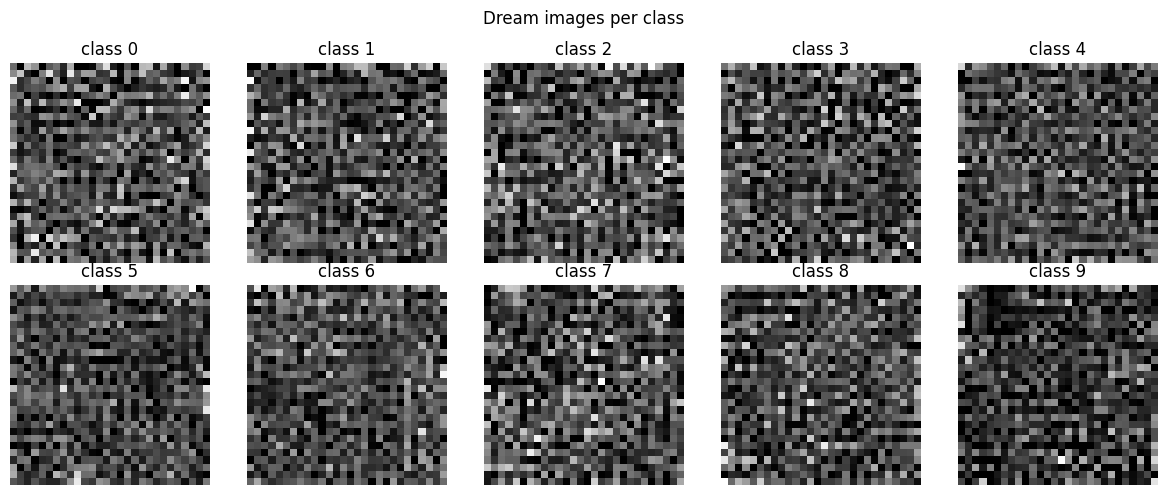

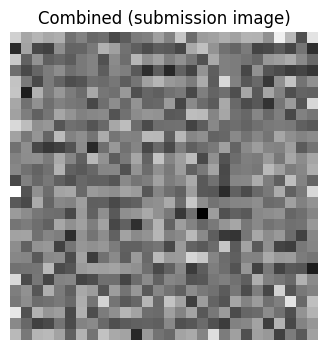

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd

seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

# ── модель (точь-в-точь как в условии) ──────────────────────────────────────
class ConvNet(nn.Module):
    def __init__(self, num_classes=10, width=32):
        super().__init__()
        self.f = nn.Sequential(
            nn.Conv2d(1, width, 3, padding=1),
            nn.InstanceNorm2d(width, affine=True),
            nn.ReLU(inplace=True),
            nn.AvgPool2d(2),
            nn.Conv2d(width, width, 3, padding=1),
            nn.InstanceNorm2d(width, affine=True),
            nn.ReLU(inplace=True),
            nn.AvgPool2d(2),
        )
        self.fc = nn.Linear(width * 7 * 7, num_classes)
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
                nn.init.zeros_(m.bias)
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0.0, 0.01)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.fc(self.f(x).flatten(1))

# ── инициализируем модель с тем же seed ─────────────────────────────────────
model = ConvNet()
model.eval()

# замораживаем веса — оптимизируем только пиксели
for p in model.parameters():
    p.requires_grad_(False)

print("Модель инициализирована (seed=42)")

# ── gradient ascent по пикселям для каждого класса ──────────────────────────
def get_dream_image(model, target_class, steps=500, lr=0.05):
    # стартуем с серого (0.5) + небольшой шум
    pixels = torch.full((1, 1, 28, 28), 0.5) + torch.randn(1, 1, 28, 28) * 0.01
    pixels.requires_grad_(True)

    optimizer = torch.optim.Adam([pixels], lr=lr)

    for step in range(steps):
        optimizer.zero_grad()
        logits = model(pixels)
        
        # максимизируем logit нужного класса
        loss = -logits[0, target_class]
        loss.backward()
        optimizer.step()

        # клампируем в разумный диапазон (до нормализации MNIST)
        with torch.no_grad():
            pixels.clamp_(-3.0, 3.0)

    return pixels.detach()

dream_images = []
for cls in range(10):
    img = get_dream_image(model, cls, steps=500, lr=0.05)
    dream_images.append(img)
    print(f"  класс {cls}: logit = {model(img)[0, cls].item():.3f}")

# ── комбинируем: среднее по всем 10 ─────────────────────────────────────────
combined = torch.stack(dream_images, dim=0).mean(dim=0)  # (1,1,28,28)

# денормализуем из пространства [-3,3] → [0,1]
# MNIST нормализация: mean=0.1307, std=0.3081
# x_norm = (x_raw - 0.1307) / 0.3081  →  x_raw = x_norm * 0.3081 + 0.1307
combined_raw = combined * 0.3081 + 0.1307
combined_clipped = combined_raw.clamp(0.0, 1.0)

flat_pixels = combined_clipped.flatten().numpy()
print(f"\nПиксели: min={flat_pixels.min():.3f}, max={flat_pixels.max():.3f}, mean={flat_pixels.mean():.3f}")

# ── лейбл: uniform ──────────────────────────────────────────────────────────
soft_labels = np.full(10, 0.1, dtype=np.float32)

# ── сабмишн ─────────────────────────────────────────────────────────────────
row = {"id": 0}
row.update({f"p{i}": flat_pixels[i] for i in range(784)})
row.update({f"l{i}": soft_labels[i] for i in range(10)})

df = pd.DataFrame([row])
df.to_csv("submission_feature_viz.csv", index=False)
print("Сохранено: submission_feature_viz.csv")

# ── визуализация ─────────────────────────────────────────────────────────────
try:
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    for cls, (ax, img) in enumerate(zip(axes.flat, dream_images)):
        raw = (img * 0.3081 + 0.1307).clamp(0, 1).squeeze().numpy()
        ax.imshow(raw, cmap="gray")
        ax.set_title(f"class {cls}")
        ax.axis("off")
    plt.suptitle("Dream images per class")
    plt.tight_layout()
    plt.savefig("dream_images.png", dpi=100)
    print("Визуализация: dream_images.png")

    plt.figure(figsize=(4, 4))
    plt.imshow(flat_pixels.reshape(28, 28), cmap="gray")
    plt.title("Combined (submission image)")
    plt.axis("off")
    plt.savefig("combined_image.png", dpi=100)
    print("Визуализация: combined_image.png")
except Exception as e:
    print(f"matplotlib недоступен: {e}")